# Solving a Real-World Problem Using Reinforcement Learning

## Understanding the environment
- Instatiate FrozenLake-v1 and print state and action spaces
- Visualize the grid and annotate S (start), G (goal), and H (holes)
- Explain the reward structure and the effect of **slippery=True**

In [42]:
import os
import numpy as np
import gymnasium as gym
from tqdm import tqdm
import matplotlib.pyplot as plt
from gymnasium.envs.toy_text.frozen_lake import generate_random_map
import json
from datetime import datetime

In [43]:
# ----------------------------
# Hyperparameters
# ----------------------------
TOTAL_EPISODES = 20000
LEARNING_RATE = 0.8
DISCOUNT_FACTOR = 0.995
EPSILON_START = 1.0
EPSILON_END = 0.001
EPSILON_EXPONENTIAL_DECAY = 0.999
EPSILON_LINEAR_DECAY = (EPSILON_START - EPSILON_END) / TOTAL_EPISODES

EVAL_EPISODES = 10000

## Setting up the RL Agent
- Implement **tabular Q-learning** with Q-table of isze **[n_states × n_actions]**.
- Use **ε-greedy** exploration (ε decay), learning rate **α**, discount factor **γ**.
- Initialize Q(s, a) = 0 for all feasible state-action pairs.

In [44]:
class Qlearning:
    """
    Tabular Q-learning agent for discrete state and action spaces.

    Attributes:
        lr (float): Learning rate
        df (float): Discount factor
        state_size (int): Number of states
        action_size (int): Number of actions
        qtable (np.ndarray): Q-table storing state-action values of shape [state_size, action_size]
    """

    def __init__(self, learning_rate, state_size, action_size, discount_factor):
        """Initialize Q-Learning agent with Q-table."""
        self.lr = learning_rate
        self.df = discount_factor
        self.state_size = state_size
        self.action_size = action_size
        self.qtable = np.zeros((state_size, action_size))

    def reset_qtable(self):
        """Reset Q-table to zeros."""
        self.qtable = np.zeros((self.state_size, self.action_size))

    def update(self, state, action, reward, new_state):
        """
        Update Q-value using the Q-learning update rule.
        
        Q(s, a) <- Q(s, a) + α[r + γ max_a' Q(s', a') - Q(s, a)]

        Args:
            state: Current state
            action: Action taken
            reward: Reward received
            new_state: Next state after taking action


        Returns:
            Updated Q-value for the (state, action) pair
        """
        best_next_action = np.argmax(self.qtable[new_state])
        td_target = reward + self.df * self.qtable[new_state, best_next_action]
        td_error = td_target - self.qtable[state, action]
        self.qtable[state, action] += self.lr * td_error
        return self.qtable[state, action]


# ----------------------------
# Epsilon-greedy Policy
# ----------------------------
class GreedyEpsilon:
  """
  Epsilon-greedy policy for action selection.

  With probability epsilon, select a random action (exploration).
  Otherwise, select the action with the highest Q-value (exploitation).

  """
  def __init__(self, epsilon):
    """Initialize policy with exploration rate."""
    self.epsilon = epsilon
    
  def select_action(self, action_space, state, qtable):
      """
      Select action based on epsilon-greedy strategy.
      
      Args:
          action_space: The action space of the environment
          state: Current state
          qtable: Q-table storing state-action values

      Returns:
          Selected action
      """

      if np.random.rand() < self.epsilon:
        return action_space.sample()
      else:
        max_ids = np.where(qtable[state] == qtable[state].max())[0]
        #print("Max IDs:", max_ids)
        return np.random.choice(max_ids)


# ----------------------------
# Random baseline Policy
# ----------------------------
def random_policy(action_space):
    """Random policy: select actions uniformly at random."""
    return action_space.sample()


# ----------------------------
# Heuristic Policy
# ----------------------------
def heuristic_policy(state, map_size, action_space):
  """
  Simple heuristic policy: try to move toward the goal.

  This assumes th goal is at the bottom-right corner of the grid.
  Converts state to (row, col) and chooses action to reduce distance to goal.


  Args:
      state: Current state index
      map_size: Size of the grid (e.g, 6 for 6x6)
      action_space: The action space of the environment


  Returns:
    Action that moves toward goal (or random if at goal)
  """

  row = state // map_size
  col = state % map_size
  goal_row = map_size - 1
  goal_col = map_size - 1

  # Actions: 0=Left, 1=Down, 2=Right, 3=Up
  if row < goal_row and col < goal_col:
    # Randomly choose between Down and Right
    return np.random.choice([1, 2])
  elif row < goal_row:
    return 1  # Down
  elif col < goal_col:
    return 2  # Right
  else:
    return action_space.sample()  # Random action if at goal row or column
  

## Training the RL Agent
- Train over many episodes (e.g., 10k+) to handle sparse rewards and slippage.
- Tune **α, γ, ε schedule**; track episode returns and success rate.
- Consider separate runs for 6×6 and 8×8 maps to compare difficulty.

In [45]:
# ----------------------------
# Training Loop
# ----------------------------
def train_qlearning(env, learner, policy, total_episodes, epsilon_strat='exponential'):
    """
    Train Q-learning agent.
    
    Args:
        env: Gym environment
        learner: Qlearning agent
        policy: Epsilon-greedy policy
        total_episodes: Number of training episodes
        epsilon_strat: 'linear' or 'exponential' decay strategy for epsilon
        
    Returns:
        rewards: Array of episode rewards
        steps: Array of episode lengths
        success_flags: Boolean array of successful episodes
    """
    rewards = np.zeros(total_episodes)
    steps = np.zeros(total_episodes)
    epsilon = EPSILON_START
    success_flags = np.zeros(total_episodes, dtype=bool)

    print(f"Starting training for {total_episodes} episodes with {epsilon_strat} epsilon decay.")
    
    for episode in tqdm(range(total_episodes), desc="Training"):
        state, _ = env.reset()
        done = False
        total_reward = 0
        step = 0

        policy.epsilon = max(EPSILON_END, epsilon)

        while not done:
            action = policy.select_action(env.action_space, state, learner.qtable)
            new_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            learner.update(state, action, reward, new_state)
            total_reward += reward
            step += 1
            state = new_state

        rewards[episode] = total_reward
        steps[episode] = step
        success_flags[episode] = (total_reward > 0)

        # Decay epsilon
        if epsilon_strat.lower() == 'linear':
            epsilon -= EPSILON_LINEAR_DECAY  # decay after each episode
        else:
            epsilon *= EPSILON_EXPONENTIAL_DECAY  # decay after each episode

    return rewards, steps, success_flags

## Evaluation
- Report **success rate** (fraction of episodes reaching the goal).
- Plot the **cumulative reward per episode** and a moving average.
- Compare against:
    - **Random policy** baseline.
    - **Simple heuristic** (e.g., always attempt a shortest deterministic route) to show why planning fails on slippery floors.

In [46]:
def evaluate_policy(env, qtable, episodes=EVAL_EPISODES):
    """
    Evaluate a learned Q-table policy (greedy).
    
    Args:
        env: Gym environment
        qtable: Learned Q-table
        episodes: Number of evaluation episodes

    Returns:
        success_rate: Percentage of successful episodes
        avg_steps: Average steps per episode
        avg_reward: Average reward per episode
    """
    successes = 0
    total_steps = 0
    total_reward = 0

    for _ in range(episodes):
        state, _ = env.reset()
        done = False
        steps = 0
        episode_reward = 0

        while not done:
            # Greedy action selection
            action = np.argmax(qtable[state])
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode_reward += reward
            steps += 1

            # Prevent infinite loops
            if steps > 200:
                break

        if episode_reward > 0:
            successes += 1
        
        total_steps += steps
        total_reward += episode_reward
    
    success_rate = (successes / episodes) * 100
    avg_steps = total_steps / episodes
    avg_reward = total_reward / episodes

    return success_rate, avg_steps, avg_reward

def random_policy_eval(env, episodes=1000):
    """
    Evaluate random policy baseline.

    Args:
        env: Gym environment
        episodes: Number of evaluation episodes

    Returns:
        success_rate: Percentage of successful episodes
        avg_steps: Average steps per episode
        avg_reward: Average reward per episode
    """
    successes = 0
    total_steps = 0
    total_reward = 0

    for _ in range(episodes):
        state, _ = env.reset()
        done = False
        steps = 0
        episode_reward = 0

        while not done:
            action = random_policy(env.action_space)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode_reward += reward
            steps += 1
            
            # Prevent infinite loops
            if steps > 200:
                break

        if episode_reward > 0:
            successes += 1
        total_steps += steps
        total_reward += episode_reward

    success_rate = (successes / episodes) * 100
    avg_steps = total_steps / episodes
    avg_reward = total_reward / episodes
    
    return success_rate, avg_steps, avg_reward


def evaluate_heuristic_baseline(env, map_szie, episodes=EVAL_EPISODES):
    """
    Evaluate heurtistic policy baseline.

    Args:
        env: Gym environment
        map_size: Grid size
        episodes: Number of evaluation episodes

    Returns:
        success_rate: Percentage of successful episodes
        avg_steps: Average steps per episode
        avg_reward: Average reward per episode
    """
    successes = 0
    total_steps = 0
    total_reward = 0

    for _ in range(episodes):
        state, _ = env.reset()
        done = False
        steps = 0
        episode_reward = 0

        while not done:
            action = heuristic_policy(state, map_szie, env.action_space)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode_reward += reward
            steps += 1
            
            # Prevent infinite loops
            if steps > 200:
                break
            
        if episode_reward > 0:
            successes += 1
        total_steps += steps
        total_reward += episode_reward

    success_rate = (successes / episodes) * 100
    avg_steps = total_steps / episodes
    avg_reward = total_reward / episodes
    
    return success_rate, avg_steps, avg_reward

In [47]:
def visualize_grid(env, map_size):
    """
    Visualize the FrozenLake grid with legend.

    Args:
        env: Gym environment
        map_size: Size of the grid
    """
    print("\n"+"="*50)
    print(f"FrozenLake {map_size}x{map_size} Grid Visualization")
    print("="*50)
    print("\nLegend:")
    print("  S = Start (Loading Bay)")
    print("  F = Frozen (Safe tile)")
    print("  H = Hole (Hazard/Spill zone)")
    print("  G = Goal (Target Shelf)")
    print("\nGrid Layout:")
    print(env.render())
    print("="*50 + "\n")

In [48]:
def plot_training_curves(rewards, steps, success_flags, map_size, epsilon_strat, window=500):
    """
    Plot training curves: rewards and success rate over episodes.
    
    Args:
        rewards: Episode rewards
        steps: Episode lengths
        success_flags: Boolean array of successful episodes
        map_size: Grid size
        epsilon_strat: Epsilon decay strategy
        window: Moving average window size
    """

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Plot 1: Episode Rewards with Moving Average
    moving_avg = np.convolve(rewards, np.ones(window)/window, mode="valid")
    axes[0, 0].plot(rewards, alpha=0.3, label="Episode Reward")
    axes[0, 0].plot(np.arange(window-1, len(rewards)), moving_avg, 
                    color="red", linewidth=2, label=f"Moving Average ({window})")
    axes[0, 0].set_xlabel("Episodes")
    axes[0, 0].set_ylabel("Reward")
    axes[0, 0].set_title(f"Episode Rewards - {map_size}×{map_size} ({epsilon_strat.capitalize()})")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Cumulative Reward
    cumulative_reward = np.cumsum(rewards)
    axes[0, 1].plot(cumulative_reward, color="green")
    axes[0, 1].set_xlabel("Episodes")
    axes[0, 1].set_ylabel("Cumulative Reward")
    axes[0, 1].set_title(f"Cumulative Reward - {map_size}×{map_size}")
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Success Rate (Moving Average)
    success_rate_moving = np.convolve(success_flags.astype(float), 
                                      np.ones(window)/window, mode="valid") * 100
    axes[1, 0].plot(np.arange(window-1, len(success_flags)), success_rate_moving, 
                    color="purple", linewidth=2)
    axes[1, 0].set_xlabel("Episodes")
    axes[1, 0].set_ylabel("Success Rate (%)")
    axes[1, 0].set_title(f"Success Rate - {map_size}×{map_size} (Window={window})")
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Episode Length with Moving Average
    steps_moving_avg = np.convolve(steps, np.ones(window)/window, mode="valid")
    axes[1, 1].plot(steps, alpha=0.3, label="Episode Length")
    axes[1, 1].plot(np.arange(window-1, len(steps)), steps_moving_avg, 
                    color="orange", linewidth=2, label=f"Moving Average ({window})")
    axes[1, 1].set_xlabel("Episodes")
    axes[1, 1].set_ylabel("Steps")
    axes[1, 1].set_title(f"Episode Length - {map_size}×{map_size}")
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    return fig

In [49]:
def plot_comparison(results_dict, map_size, epsilon_strat):
    """
    Plot comparison of different algorithms and baselines.
    
    Args:
        results_dict: Dictionary with algorithm names as keys and metrics as values
        map_size: Grid size
    """
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    algorithms = list(results_dict.keys())
    success_rates = [results_dict[alg]['success_rate'] for alg in algorithms]
    avg_steps = [results_dict[alg]['avg_steps'] for alg in algorithms]
    
    x = np.arange(len(algorithms))
    width = 0.35
    
    ax.bar(x - width/2, success_rates, width, label='Success Rate (%)', color='skyblue')
    ax.bar(x + width/2, avg_steps, width, label='Avg Steps', color='lightcoral')
    
    ax.set_xlabel('Algorithm / Policy')
    ax.set_ylabel('Value')
    ax.set_title(f'Performance Comparison - {map_size}×{map_size} FrozenLake ({epsilon_strat.capitalize()})')
    ax.set_xticks(x)
    ax.set_xticklabels(algorithms, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    return fig

In [50]:
config = {
    1: {"map_size": 6, "epsilon_strat": "linear"},
    3: {"map_size": 6, "epsilon_strat": "exponential"},
    2: {"map_size": 8, "epsilon_strat": "linear"},
    4: {"map_size": 8, "epsilon_strat": "exponential"}
}


--- Training on FrozenLake 6×6 ---

--- TASK1: Understanding the Environment ---
State Space: Discrete(36) (Discrete with 36 states)
Action Space: Discrete(4) (Discrete with 4 actions)
Actions: 0=Left, 1=Down, 2=Right, 3=Up

Reward Structure:
  - Reaching Goal (G): +1
  - Falling in Hole (H): 0 (episode terminates)
  - Safe tiles (F): 0 (sparse reward)

Slippery Effect (is_slippery=True):
  - Intended action may not execute perfectly
  - Agent may slip to adjacent directions
  - Models real-world uncertainty (slippery warehouse floor)

FrozenLake 6x6 Grid Visualization

Legend:
  S = Start (Loading Bay)
  F = Frozen (Safe tile)
  H = Hole (Hazard/Spill zone)
  G = Goal (Target Shelf)

Grid Layout:

SFFFHF
FFFFFH
FHHFFF
HFFFFF
FFFHFF
FFFHFG



--- TASK 2 & 3: Training Q-Learning Agent ---
Starting training for 20000 episodes with linear epsilon decay.


Training: 100%|██████████| 20000/20000 [00:05<00:00, 3625.22it/s]



Training Success Rate: 5.38%

--- TASK 4: Evaluation ---

--- Evaluating trained Q-learning policy ---
  Q-Learning - Success Rate: 29.84%, Avg Steps: 85.62, Avg Reward: 0.298

--- Evaluating random policy baseline ---
  Random Policy - Success Rate: 0.47%, Avg Steps: 12.83, Avg Reward: 0.005

--- Evaluating heuristic policy baseline ---


/var/folders/fn/nb_wvnys4vv2437k8n5w_9f80000gn/T/ipykernel_29727/3014460795.py:87: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()
/var/folders/fn/nb_wvnys4vv2437k8n5w_9f80000gn/T/ipykernel_29727/3014460795.py:91: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


  Heuristic Policy - Success Rate: 3.90%, Avg Steps: 8.17, Avg Reward: 0.039

--- Generating Plots ---

--- Training on FrozenLake 6×6 ---

--- TASK1: Understanding the Environment ---
State Space: Discrete(36) (Discrete with 36 states)
Action Space: Discrete(4) (Discrete with 4 actions)
Actions: 0=Left, 1=Down, 2=Right, 3=Up

Reward Structure:
  - Reaching Goal (G): +1
  - Falling in Hole (H): 0 (episode terminates)
  - Safe tiles (F): 0 (sparse reward)

Slippery Effect (is_slippery=True):
  - Intended action may not execute perfectly
  - Agent may slip to adjacent directions
  - Models real-world uncertainty (slippery warehouse floor)

FrozenLake 6x6 Grid Visualization

Legend:
  S = Start (Loading Bay)
  F = Frozen (Safe tile)
  H = Hole (Hazard/Spill zone)
  G = Goal (Target Shelf)

Grid Layout:

SFFFHF
FFFFFH
FHHFFF
HFFFFF
FFFHFF
FFFHFG



--- TASK 2 & 3: Training Q-Learning Agent ---
Starting training for 20000 episodes with exponential epsilon decay.


...

/var/folders/fn/nb_wvnys4vv2437k8n5w_9f80000gn/T/ipykernel_29727/3014460795.py:87: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()
/var/folders/fn/nb_wvnys4vv2437k8n5w_9f80000gn/T/ipykernel_29727/3014460795.py:91: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


  Heuristic Policy - Success Rate: 5.07%, Avg Steps: 7.85, Avg Reward: 0.051

--- Generating Plots ---

--- Training on FrozenLake 8×8 ---

--- TASK1: Understanding the Environment ---
State Space: Discrete(64) (Discrete with 64 states)
Action Space: Discrete(4) (Discrete with 4 actions)
Actions: 0=Left, 1=Down, 2=Right, 3=Up

Reward Structure:
  - Reaching Goal (G): +1
  - Falling in Hole (H): 0 (episode terminates)
  - Safe tiles (F): 0 (sparse reward)

Slippery Effect (is_slippery=True):
  - Intended action may not execute perfectly
  - Agent may slip to adjacent directions
  - Models real-world uncertainty (slippery warehouse floor)

FrozenLake 8x8 Grid Visualization

Legend:
  S = Start (Loading Bay)
  F = Frozen (Safe tile)
  H = Hole (Hazard/Spill zone)
  G = Goal (Target Shelf)

Grid Layout:

SHFFHFFF
FFFFFFHF
FFFFHFFF
FFFFFFFF
FFFFFFHF
HFHFFFFF
FFFFFFFF
FFFFFFFG



--- TASK 2 & 3: Training Q-Learning Agent ---
Starting training for 20000 episodes with exponential epsilon decay

Training: 100%|██████████| 20000/20000 [00:18<00:00, 1092.41it/s]



Training Success Rate: 41.08%

--- TASK 4: Evaluation ---

--- Evaluating trained Q-learning policy ---
  Q-Learning - Success Rate: 57.89%, Avg Steps: 77.03, Avg Reward: 0.579

--- Evaluating random policy baseline ---
  Random Policy - Success Rate: 0.32%, Avg Steps: 8.30, Avg Reward: 0.003

--- Evaluating heuristic policy baseline ---
  Heuristic Policy - Success Rate: 5.03%, Avg Steps: 7.85, Avg Reward: 0.050

--- Generating Plots ---


/var/folders/fn/nb_wvnys4vv2437k8n5w_9f80000gn/T/ipykernel_29727/3014460795.py:87: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()
/var/folders/fn/nb_wvnys4vv2437k8n5w_9f80000gn/T/ipykernel_29727/3014460795.py:91: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


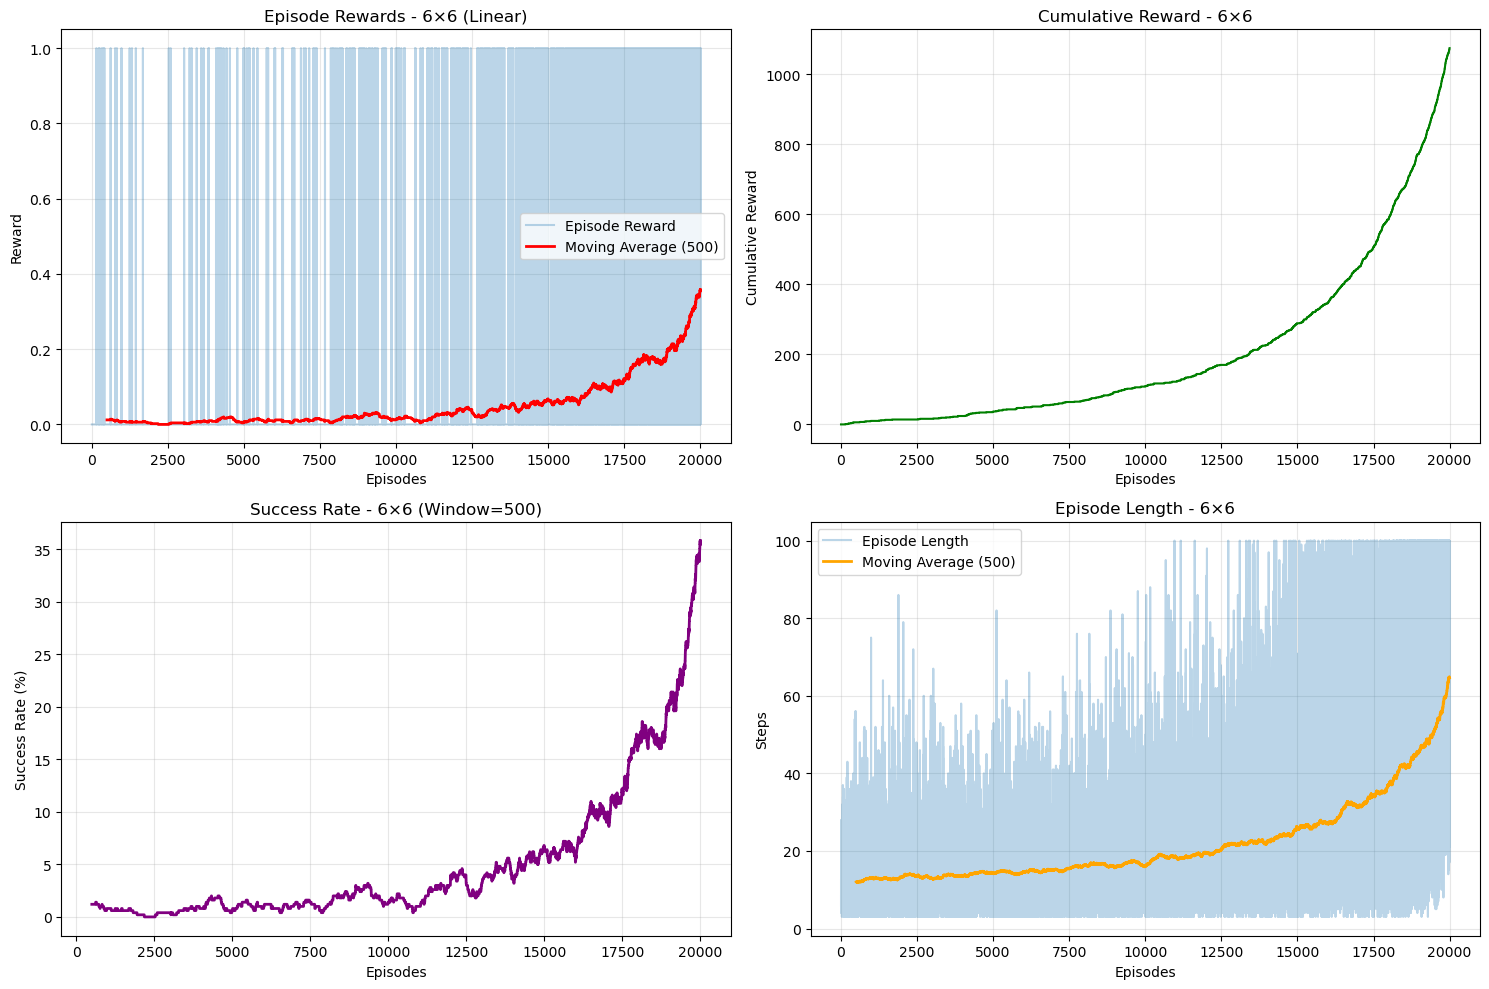

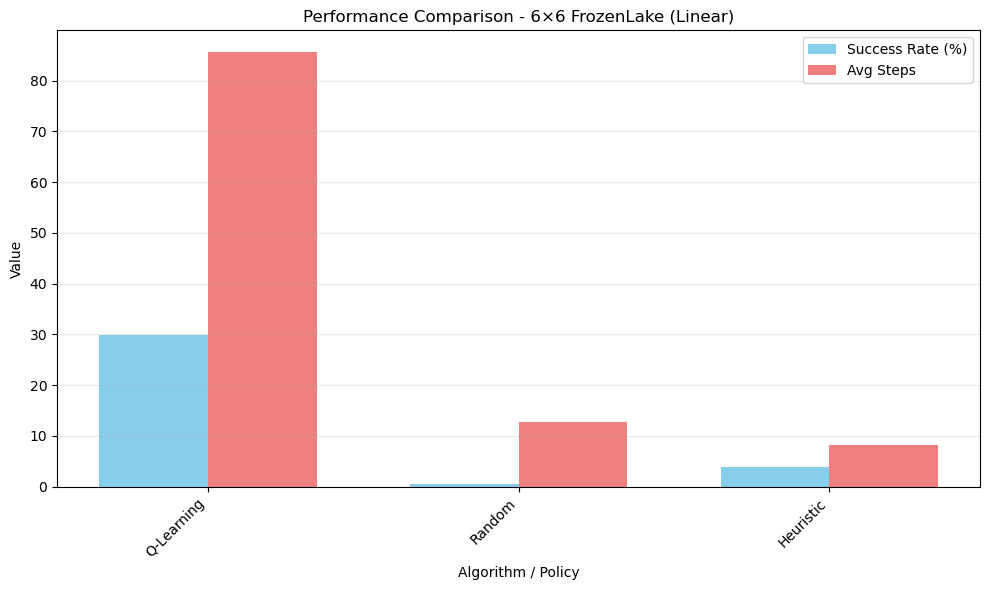

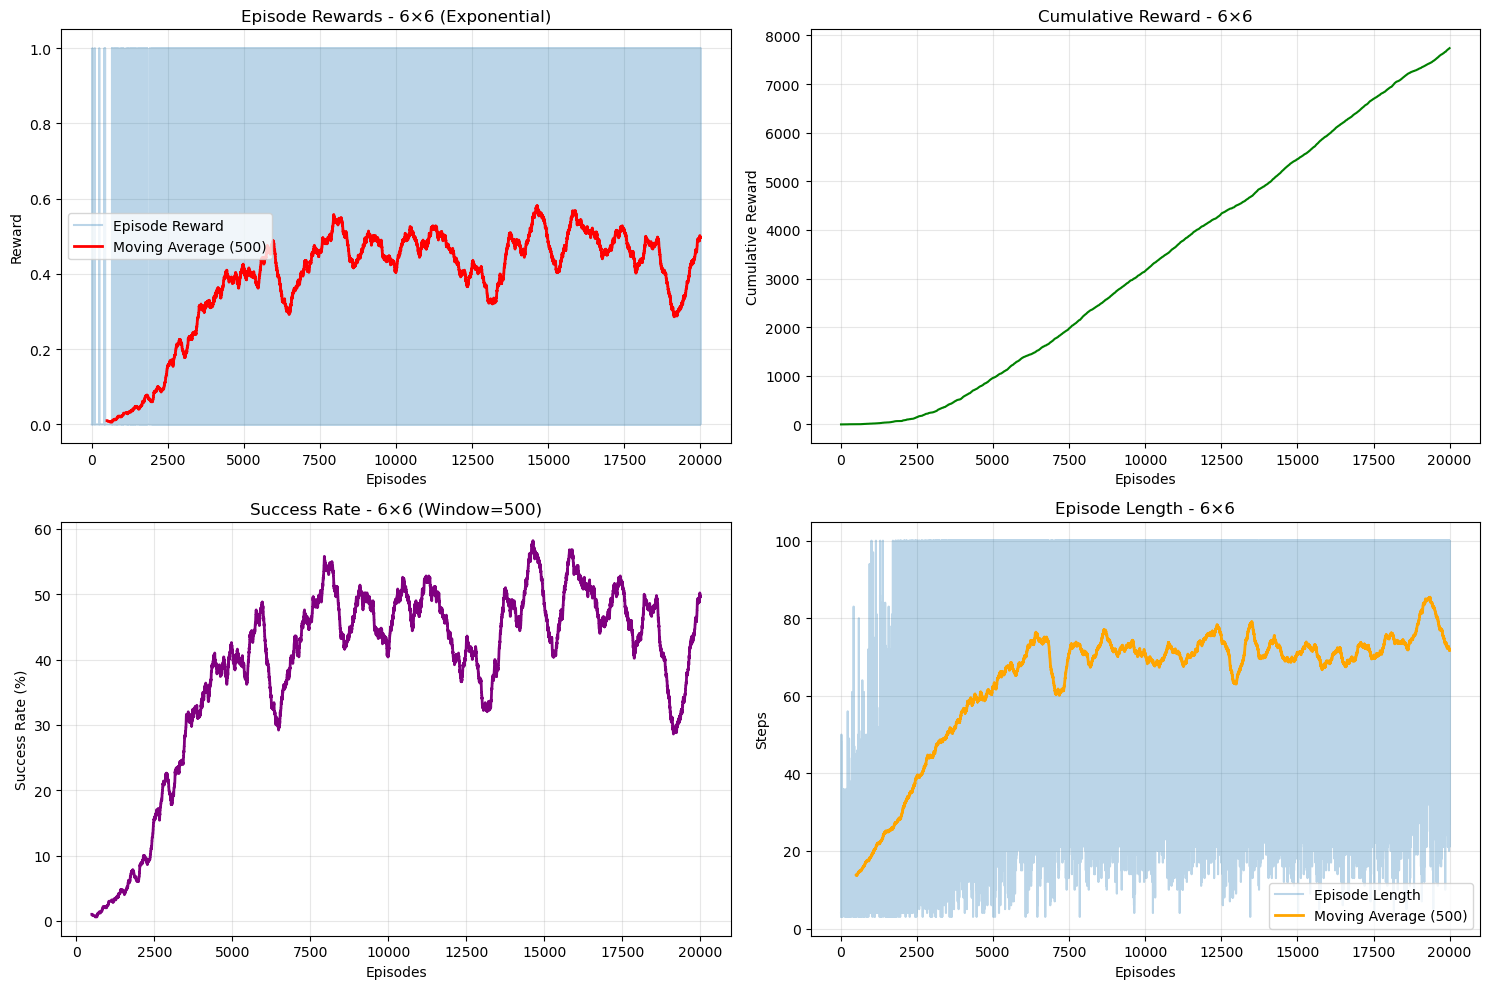

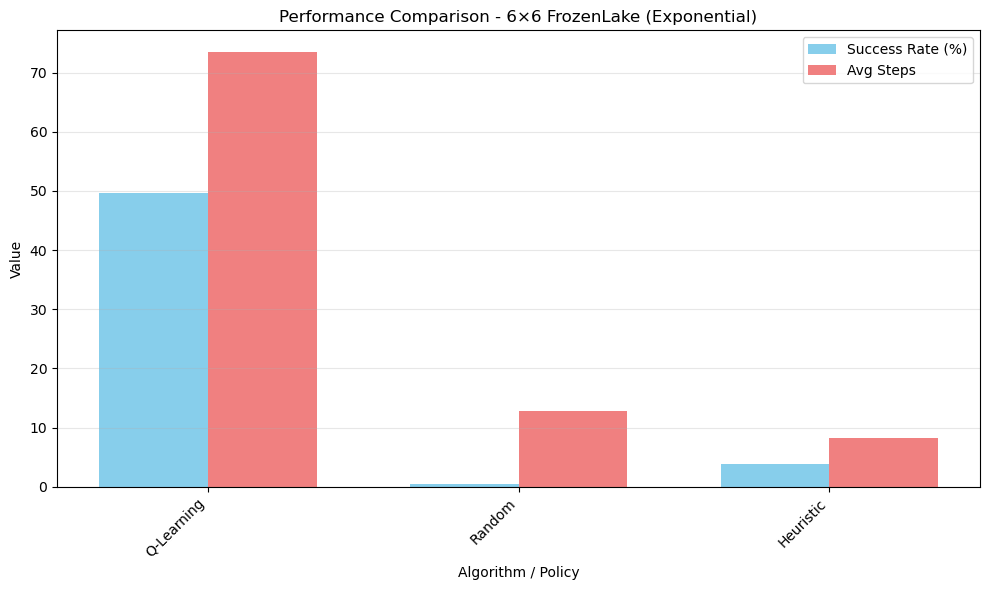

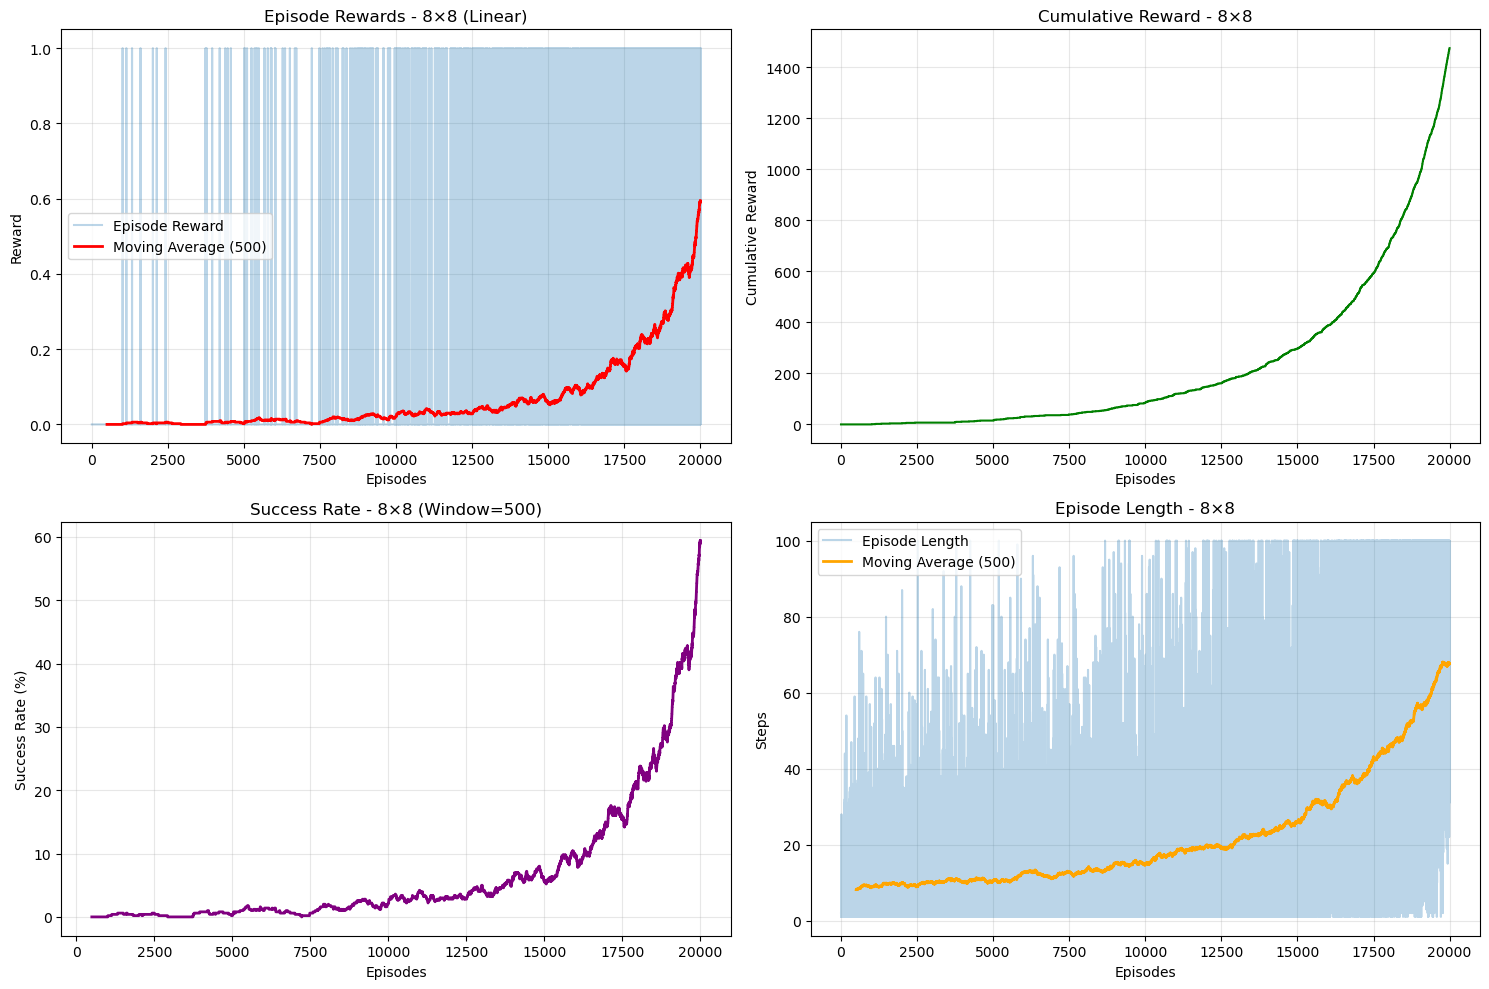

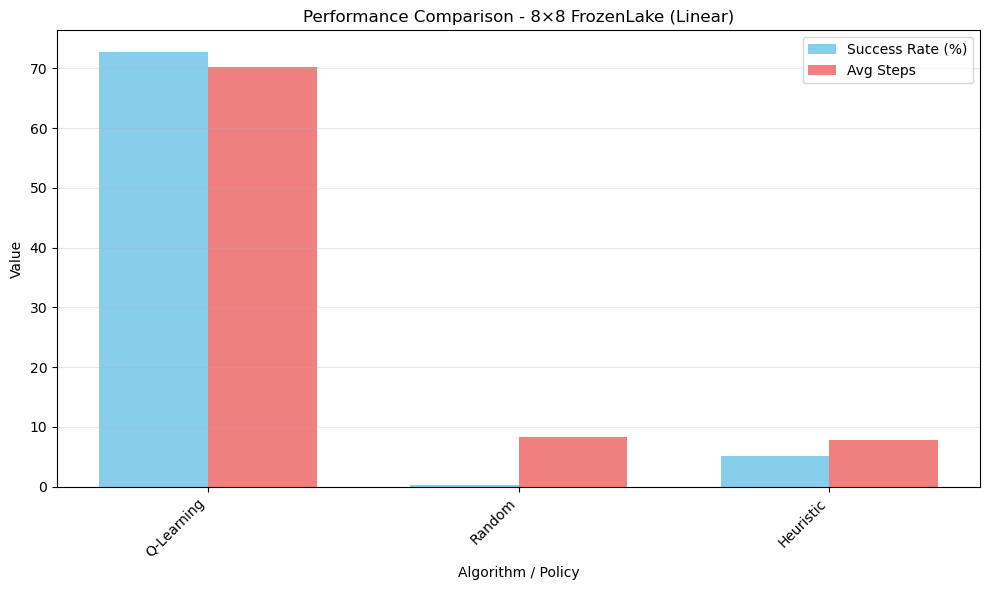

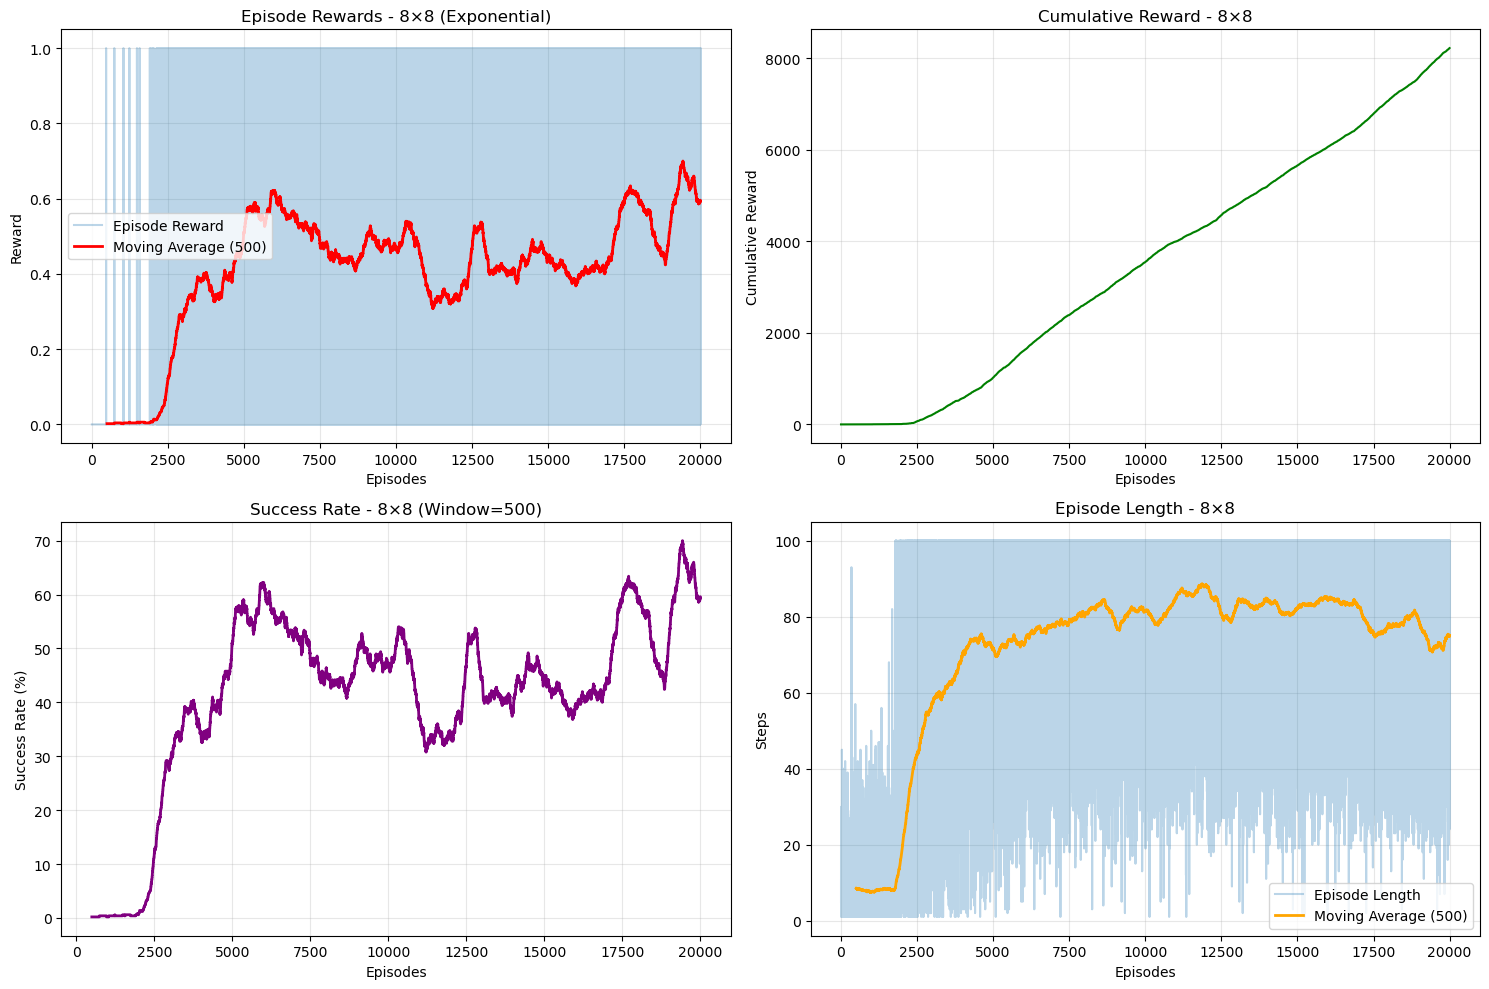

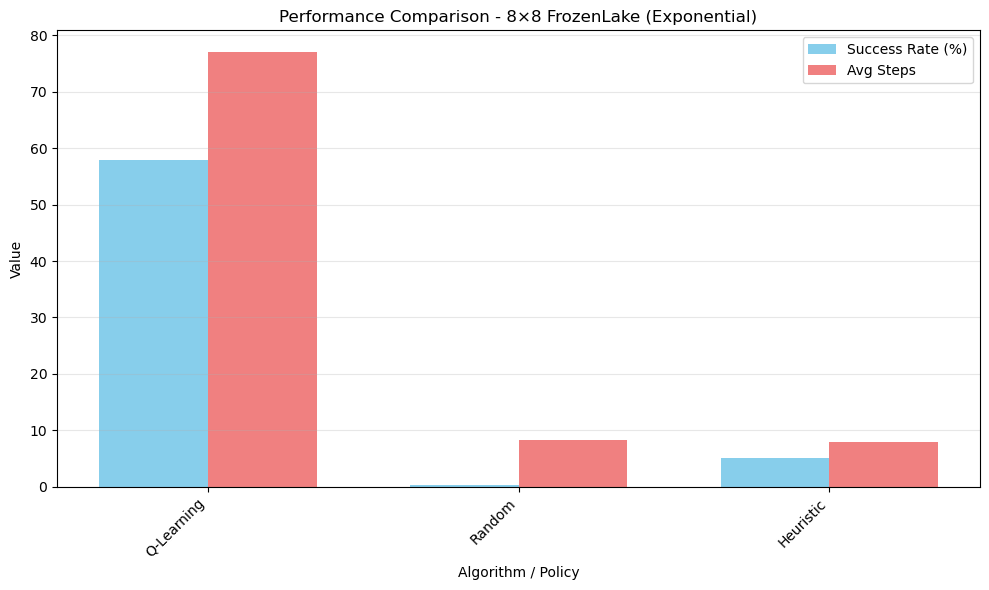

In [51]:
all_results = {}

for cfg_id, cfg in config.items():
    """
    Train and evaluate Q-learning agent on FrozenLake with given configuration.
     """
    MAP_SIZE = cfg["map_size"]
    EPSILON_STRAT = cfg["epsilon_strat"]
    print(f"\n--- Training on FrozenLake {MAP_SIZE}×{MAP_SIZE} ---")

    env = gym.make(
        "FrozenLake-v1",
        is_slippery=True,
        render_mode="ansi",
        desc=generate_random_map(size=MAP_SIZE,p=0.8, seed=MAP_SIZE)
    )
    env.reset()

    print("\n--- TASK1: Understanding the Environment ---")
    print(f"State Space: {env.observation_space} (Discrete with {env.observation_space.n} states)")
    print(f"Action Space: {env.action_space} (Discrete with {env.action_space.n} actions)")
    print(f"Actions: 0=Left, 1=Down, 2=Right, 3=Up")
    print(f"\nReward Structure:")
    print(f"  - Reaching Goal (G): +1")
    print(f"  - Falling in Hole (H): 0 (episode terminates)")
    print(f"  - Safe tiles (F): 0 (sparse reward)")
    print(f"\nSlippery Effect (is_slippery=True):")
    print(f"  - Intended action may not execute perfectly")
    print(f"  - Agent may slip to adjacent directions")
    print(f"  - Models real-world uncertainty (slippery warehouse floor)")

    visualize_grid(env, MAP_SIZE)

    print("\n--- TASK 2 & 3: Training Q-Learning Agent ---")
    learner = Qlearning(
        learning_rate=LEARNING_RATE,
        state_size=env.observation_space.n,
        action_size=env.action_space.n,
        discount_factor=DISCOUNT_FACTOR
    )


    policy = GreedyEpsilon(epsilon=EPSILON_START)

    rewards, steps, success_flags = train_qlearning(env, learner, policy, TOTAL_EPISODES, epsilon_strat=EPSILON_STRAT)

    training_success_rate = np.sum(success_flags) / TOTAL_EPISODES * 100
    print(f"\nTraining Success Rate: {training_success_rate:.2f}%")


    print("\n--- TASK 4: Evaluation ---")
    print("\n--- Evaluating trained Q-learning policy ---")
    ql_success, ql_steps, ql_reward = evaluate_policy(env, learner.qtable, EVAL_EPISODES)
    print(f"  Q-Learning - Success Rate: {ql_success:.2f}%, Avg Steps: {ql_steps:.2f}, Avg Reward: {ql_reward:.3f}")

    print("\n--- Evaluating random policy baseline ---")
    rand_success, rand_steps, rand_reward = random_policy_eval(env, EVAL_EPISODES)
    print(f"  Random Policy - Success Rate: {rand_success:.2f}%, Avg Steps: {rand_steps:.2f}, Avg Reward: {rand_reward:.3f}")

    # Evaluate Heuristic Baseline
    print("\n--- Evaluating heuristic policy baseline ---")
    heur_success, heur_steps, heur_reward = evaluate_heuristic_baseline(env, MAP_SIZE, EVAL_EPISODES)
    print(f"  Heuristic Policy - Success Rate: {heur_success:.2f}%, Avg Steps: {heur_steps:.2f}, Avg Reward: {heur_reward:.3f}")

    results = {
        'Q-Learning': {
            'success_rate': ql_success,
            'avg_steps': ql_steps,
            'avg_reward': ql_reward
        },
        'Random': {
            'success_rate': rand_success,
            'avg_steps': rand_steps,
            'avg_reward': rand_reward
        },
        'Heuristic': {
            'success_rate': heur_success,
            'avg_steps': heur_steps,
            'avg_reward': heur_reward
        }
    }

    all_results[f"FrozenLake_{MAP_SIZE}x{MAP_SIZE}_{EPSILON_STRAT}"] = results

    print("\n--- Generating Plots ---")
    fig1 = plot_training_curves(rewards, steps, success_flags, MAP_SIZE, EPSILON_STRAT)
    fig1.show()
    

    fig2 = plot_comparison(results, MAP_SIZE, EPSILON_STRAT)
    fig2.show()
    

    env.close()